# Augmentation Validation EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp


## 1. Загрузка данных

In [2]:
original_train = pd.read_csv(
    "train_original_before_synthetic.csv"
)

synthetic = pd.read_csv(
    "synthetic_objects_geo_enriched.csv"
)

print("Original train:", original_train.shape)
print("Synthetic:", synthetic.shape)


Original train: (2068, 40)
Synthetic: (4136, 40)


## 2. Соединение датасетов

In [3]:
train_augmented = pd.concat(
    [
        original_train,
        synthetic
    ],
    ignore_index=True
)

print("Augmented train:", train_augmented.shape)


Augmented train: (6204, 40)


## 3. Сохранение

In [4]:
train_augmented.to_csv(
    "train_augmented_final.csv",
    index=False
)

print("Saved: train_augmented_final.csv")


Saved: train_augmented_final.csv


## 4. Признаки для сравнения

In [5]:
compare_features = [
    "price",
    "price_per_m2",
    "area_total",
    "kitchen_area",
    "rooms",
    "floor",
    "floors_total",
    "ceiling_height",
    "build_year",
    "distance_to_center_km",
    "distance_to_mkad_km",
    "metro_distance_km",
    "distance_to_school_km",
    "distance_to_kindergarten_km",
    "distance_to_clinic_km",
    "distance_to_mall_km",
    "latitude",
    "longitude"
]

compare_features = [
    col for col in compare_features
    if (
        col in original_train.columns and
        col in train_augmented.columns
    )
]

print(compare_features)


['price', 'price_per_m2', 'area_total', 'kitchen_area', 'rooms', 'floor', 'floors_total', 'ceiling_height', 'build_year', 'distance_to_center_km', 'distance_to_mkad_km', 'metro_distance_km', 'distance_to_school_km', 'distance_to_kindergarten_km', 'distance_to_clinic_km', 'distance_to_mall_km', 'latitude', 'longitude']


## 5. Сравнение статистик

In [6]:
comparison_rows = []

for col in compare_features:

    orig = original_train[col].dropna()
    aug = train_augmented[col].dropna()

    ks_stat, ks_pvalue = ks_2samp(
        orig,
        aug
    )

    comparison_rows.append({
        "feature": col,

        "orig_mean": orig.mean(),
        "aug_mean": aug.mean(),

        "mean_diff_pct":
            (
                (aug.mean() - orig.mean())
                / orig.mean()
            ) * 100,

        "orig_std": orig.std(),
        "aug_std": aug.std(),

        "std_diff_pct":
            (
                (aug.std() - orig.std())
                / orig.std()
            ) * 100,

        "orig_min": orig.min(),
        "aug_min": aug.min(),

        "orig_max": orig.max(),
        "aug_max": aug.max(),

        "ks_statistic": ks_stat,
        "ks_pvalue": ks_pvalue
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df.to_csv(
    "augmentation_distribution_comparison.csv",
    index=False
)

comparison_df


,feature,orig_mean,aug_mean,mean_diff_pct,orig_std,aug_std,std_diff_pct,orig_min,aug_min,orig_max,aug_max,ks_statistic,ks_pvalue
0,price,2.527811e+07,2.530904e+07,0.122346,2.194194e+07,1.918360e+07,-12.571113,3.000000e+06,3.000000e+06,2.890000e+08,2.890000e+08,0.053030,3.187543e-04
1,price_per_m2,4.561657e+05,4.553224e+05,-0.184869,1.872567e+05,1.647560e+05,-12.015945,4.089027e+04,4.089027e+04,3.546012e+06,3.546012e+06,0.027724,1.824865e-01
2,area_total,5.453859e+01,5.458296e+01,0.081355,2.975284e+01,2.616664e+01,-12.053307,1.000000e+01,1.000000e+01,3.000000e+02,3.000000e+02,0.061412,1.616816e-05
3,kitchen_area,1.133431e+01,1.131563e+01,-0.164803,6.901311e+00,5.996367e+00,-13.112650,1.000000e+00,1.000000e+00,7.000000e+01,7.000000e+01,0.086396,1.662620e-10
4,rooms,1.780097e+00,1.833333e+00,2.990637,1.096904e+00,9.269287e-01,-15.495889,0.000000e+00,0.000000e+00,6.000000e+00,6.000000e+00,0.086970,1.294107e-10
5,floor,8.955996e+00,8.976950e+00,0.233969,7.821144e+00,6.811240e+00,-12.912486,1.000000e+00,1.000000e+00,5.600000e+01,5.600000e+01,0.075274,4.468084e-08
6,floors_total,1.801064e+01,1.784961e+01,-0.894056,1.083557e+01,9.407077e+00,-13.183397,1.000000e+00,1.000000e+00,7.300000e+01,7.300000e+01,0.077692,1.414328e-08
7,ceiling_height,2.751637e+00,2.750651e+00,-0.035811,2.525865e-01,2.148247e-01,-14.950065,2.400000e+00,2.400000e+00,6.000000e+00,6.000000e+00,0.176177,1.699649e-42
8,build_year,1.997822e+03,1.997667e+03,-0.007729,2.093147e+01,1.817798e+01,-13.154759,1.847000e+03,1.847000e+03,2.026000e+03,2.026000e+03,0.090909,1.377823e-11
9,distance_to_center_km,1.240786e+01,1.237625e+01,-0.254721,6.105274e+00,6.079974e+00,-0.414395,4.200000e-01,4.200000e-01,3.930000e+01,3.930000e+01,0.011767,9.818885e-01


## 6. Histogram comparison

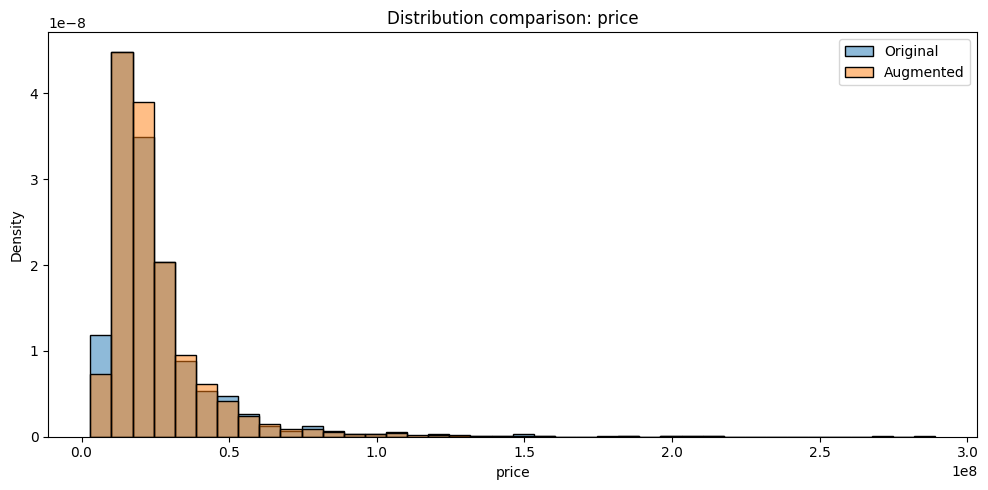

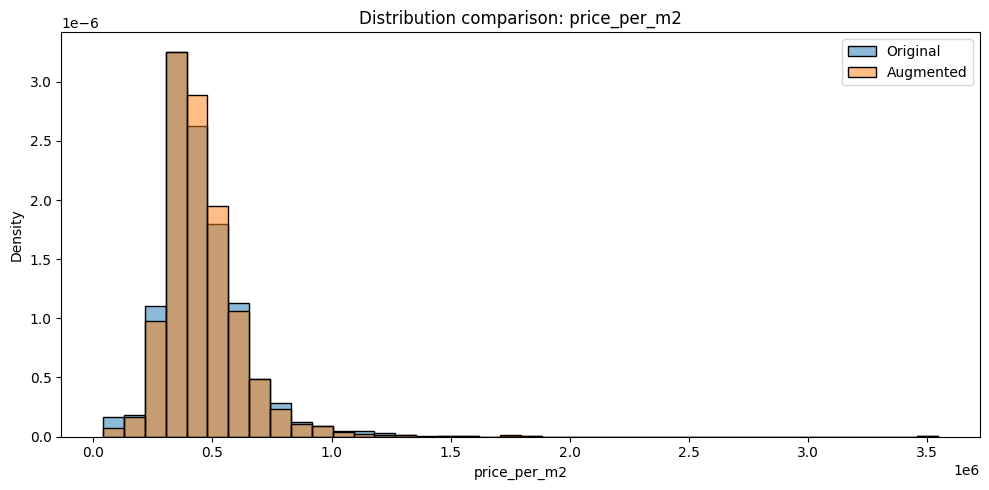

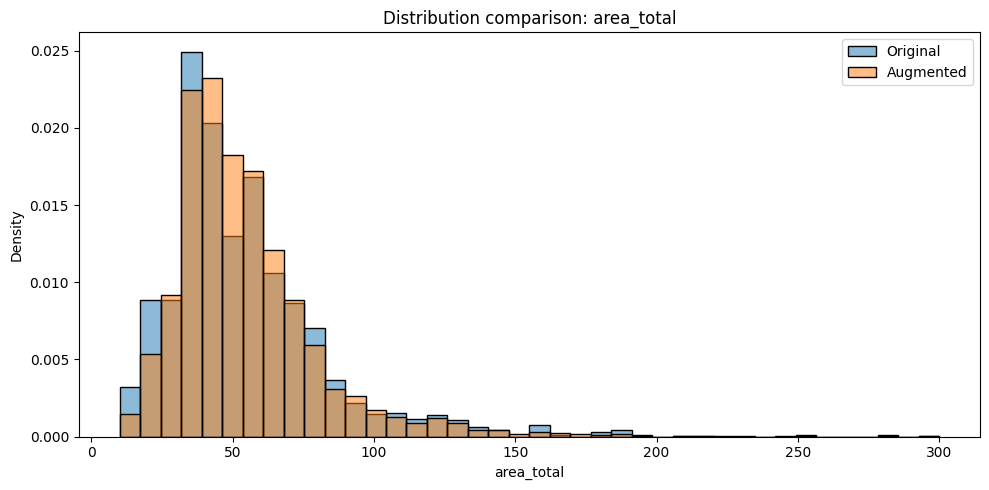

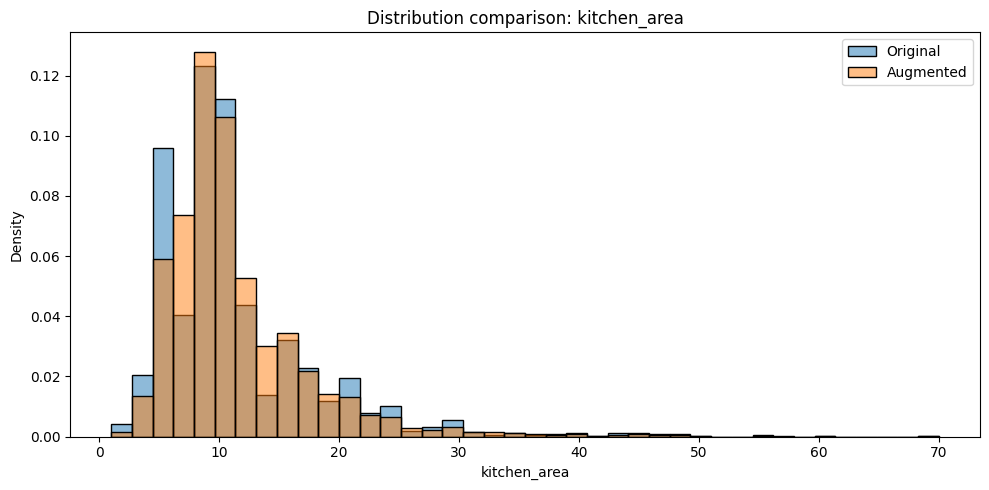

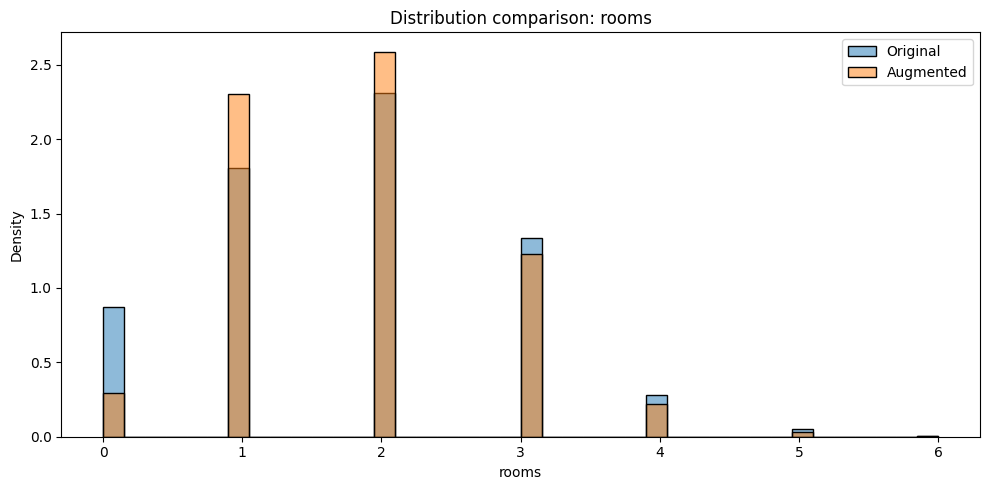

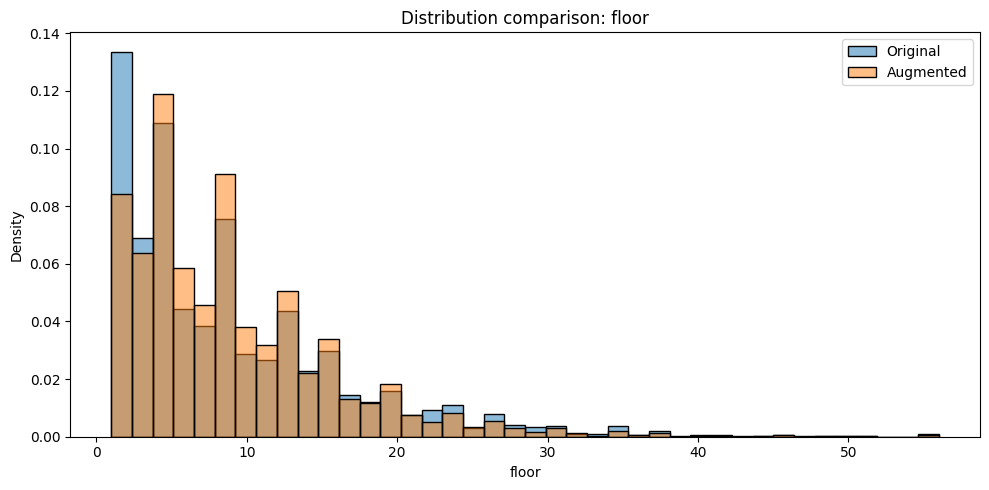

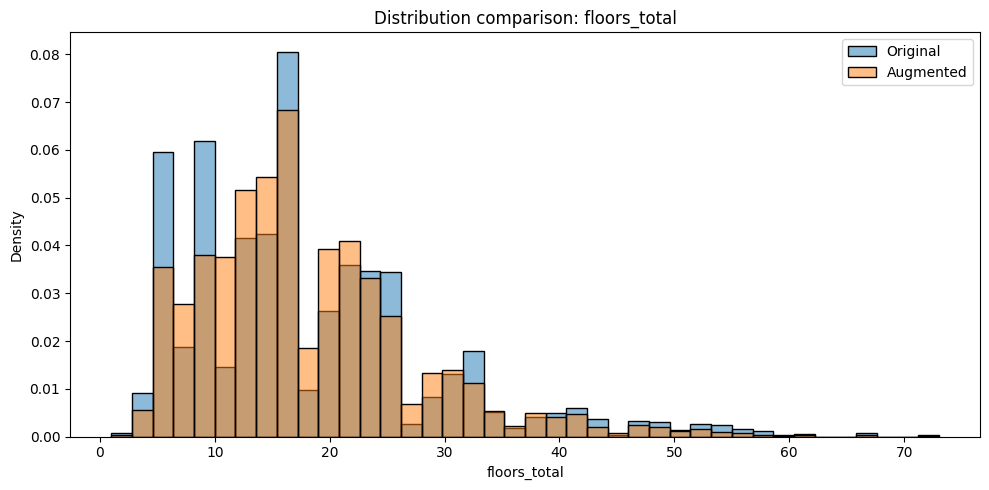

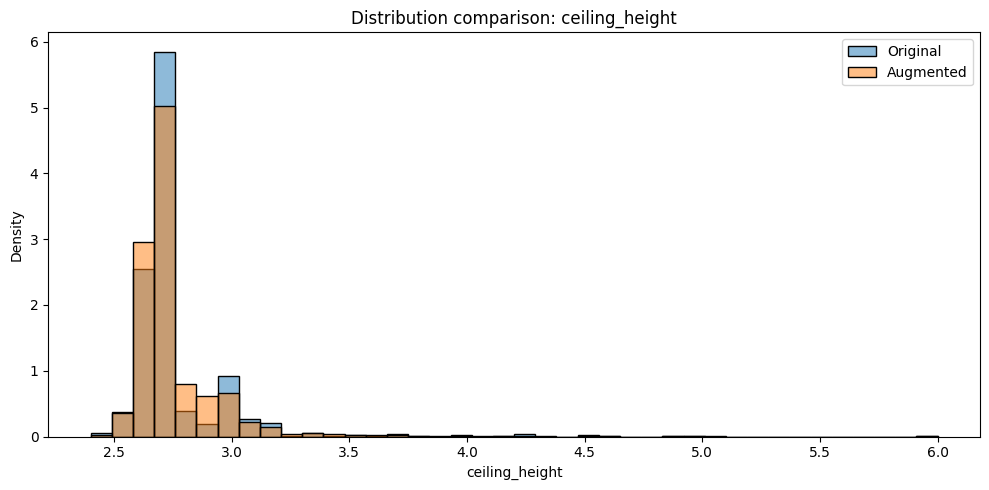

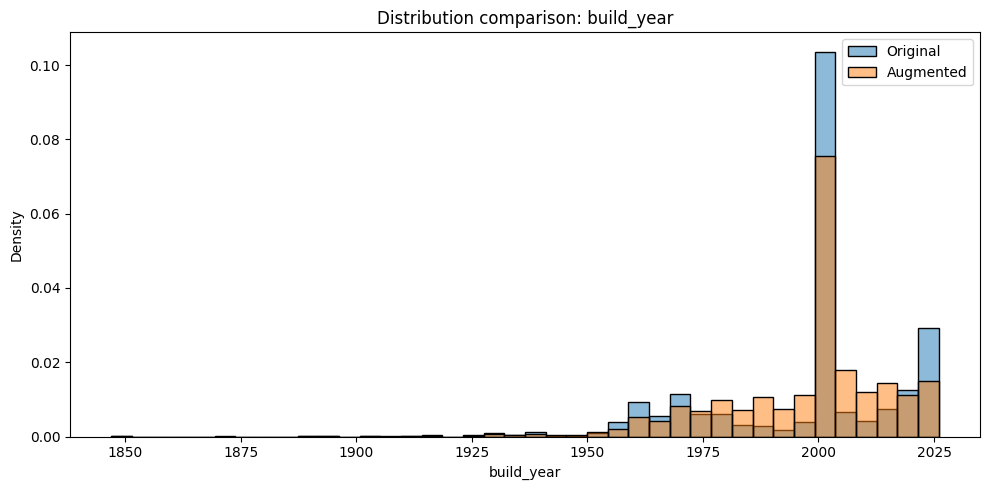

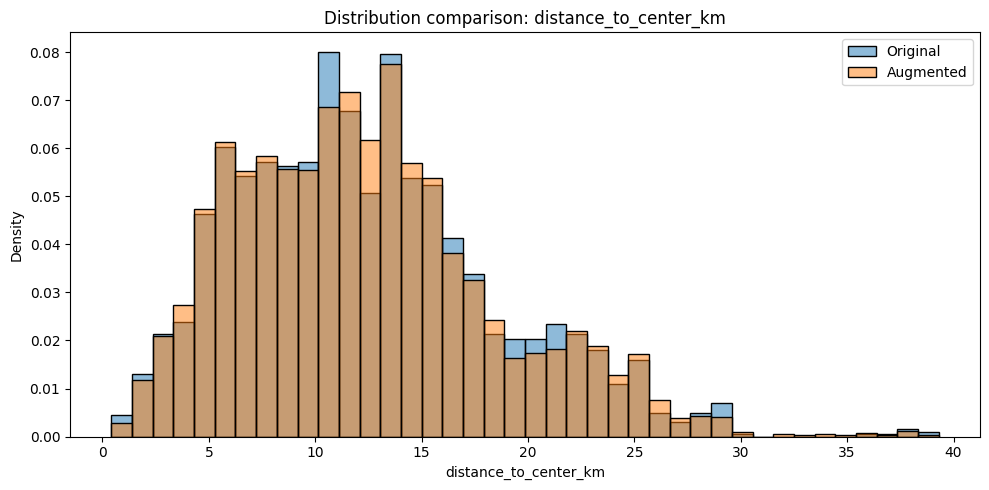

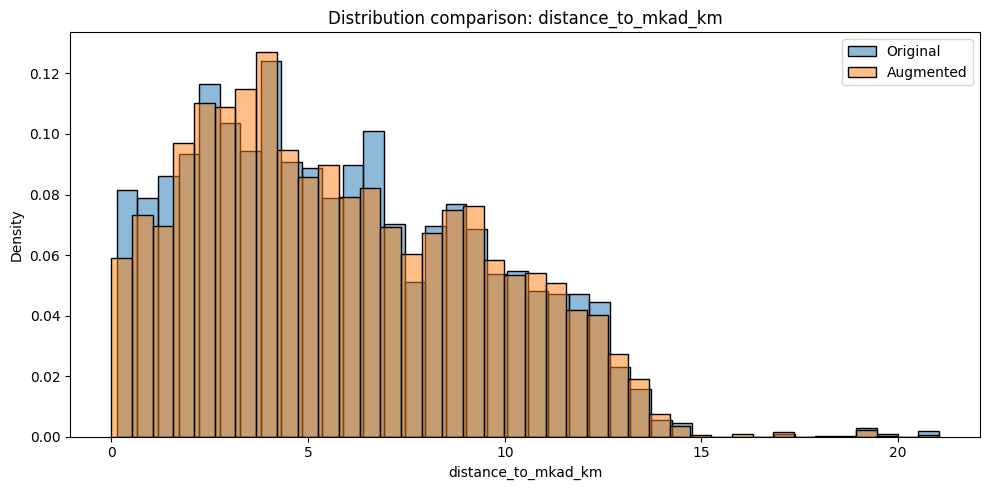

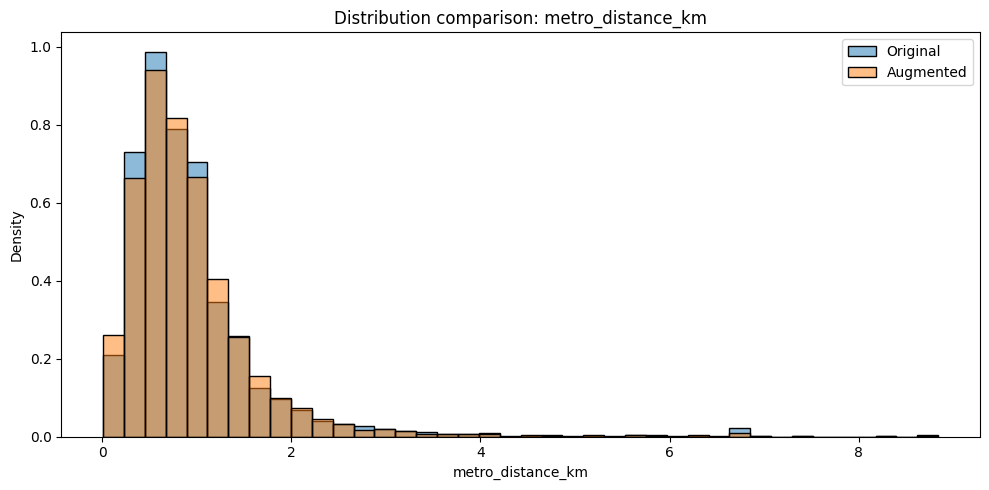

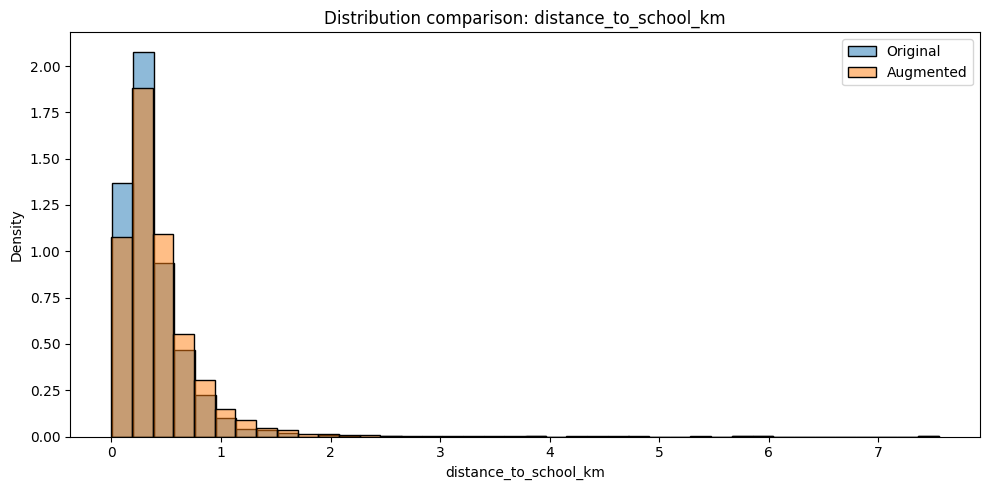

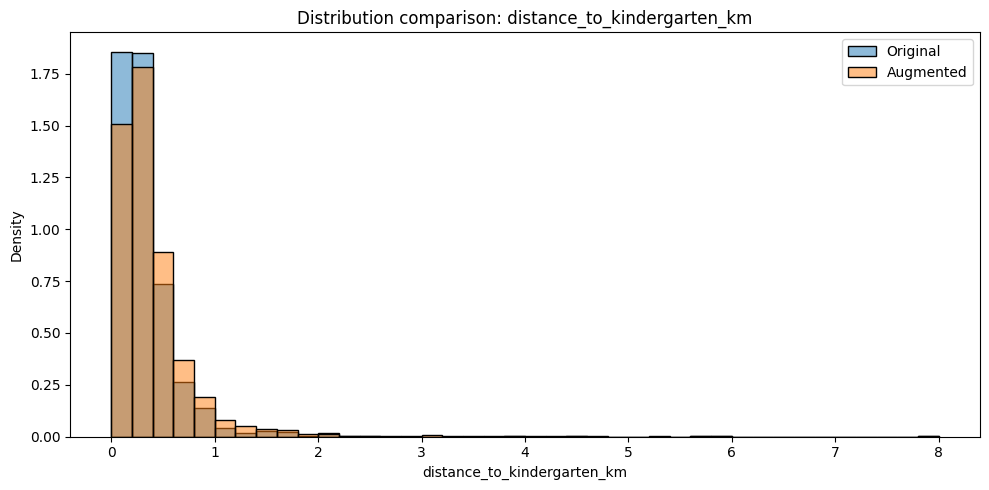

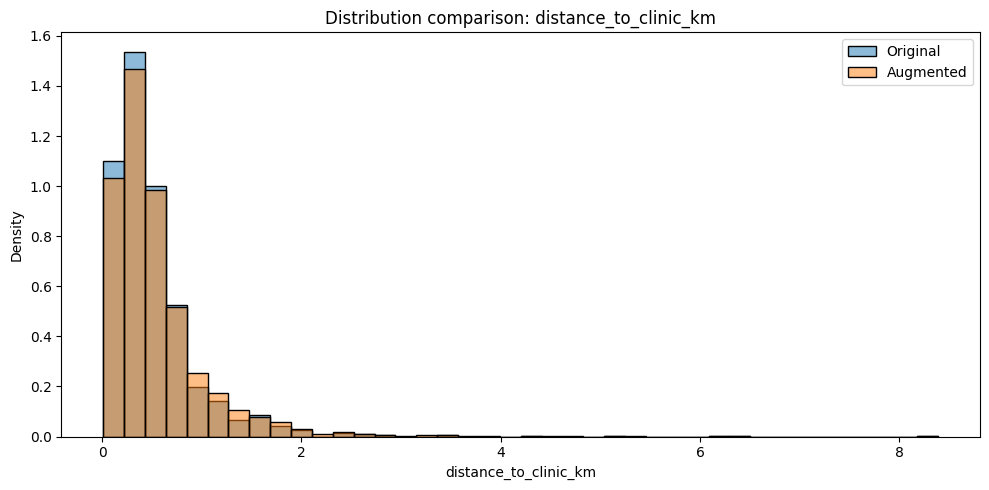

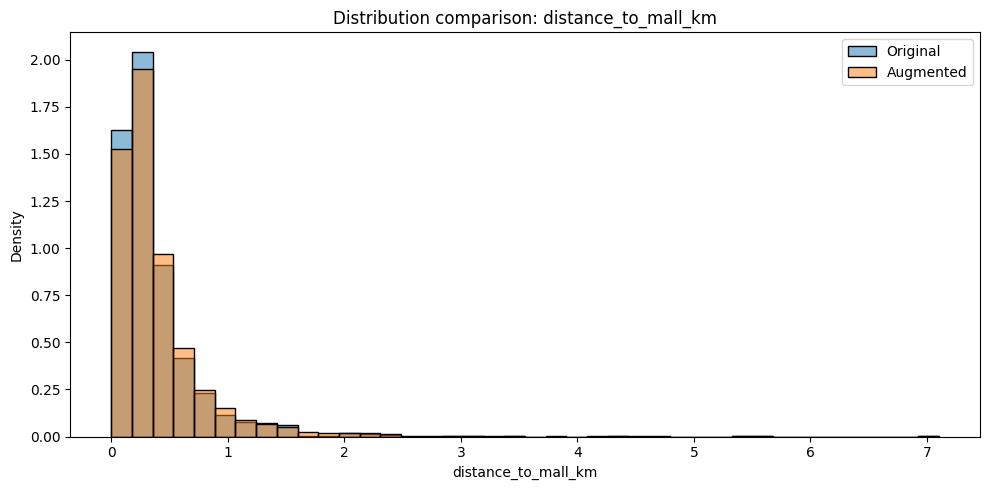

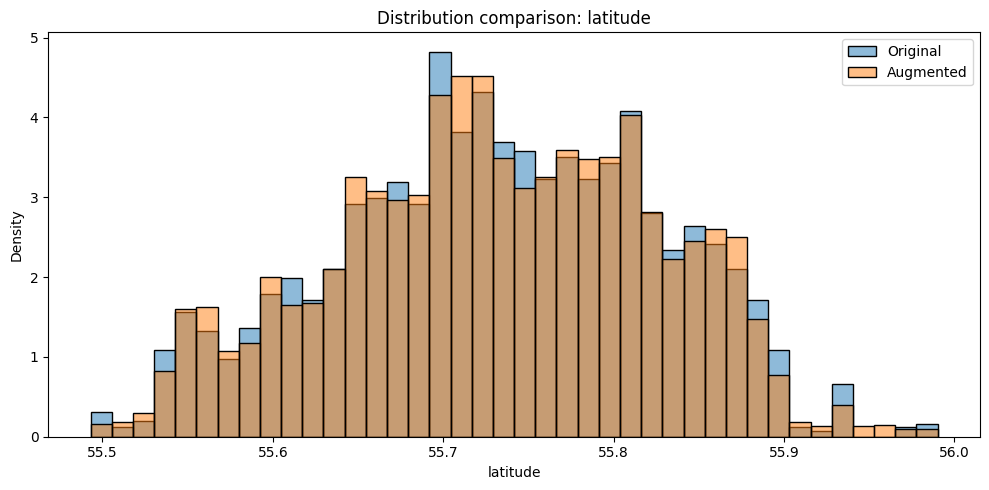

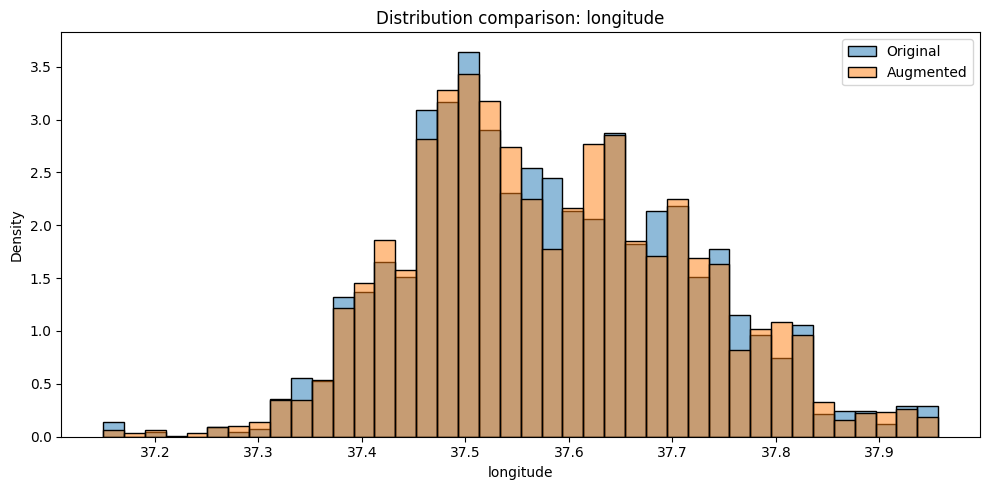

In [7]:
for feature in compare_features:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        original_train[feature],
        label="Original",
        stat="density",
        bins=40,
        alpha=0.5
    )

    sns.histplot(
        train_augmented[feature],
        label="Augmented",
        stat="density",
        bins=40,
        alpha=0.5
    )

    plt.title(
        f"Distribution comparison: {feature}"
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        f"compare_{feature}.png",
        dpi=250
    )

    plt.show()


## 7. Boxplots

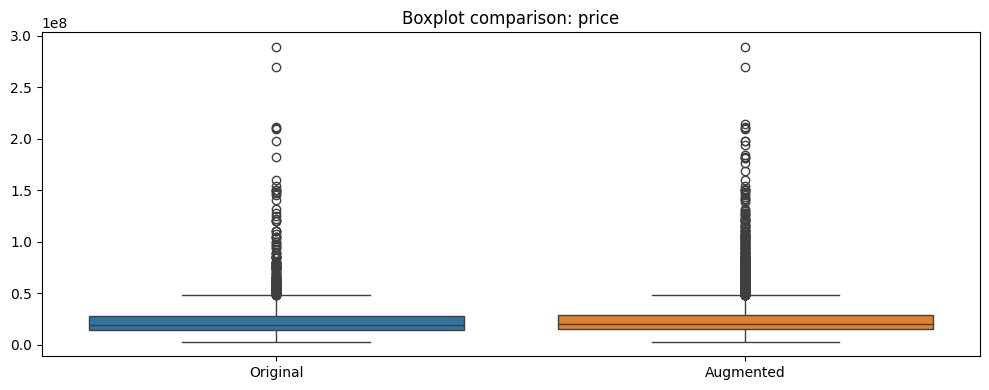

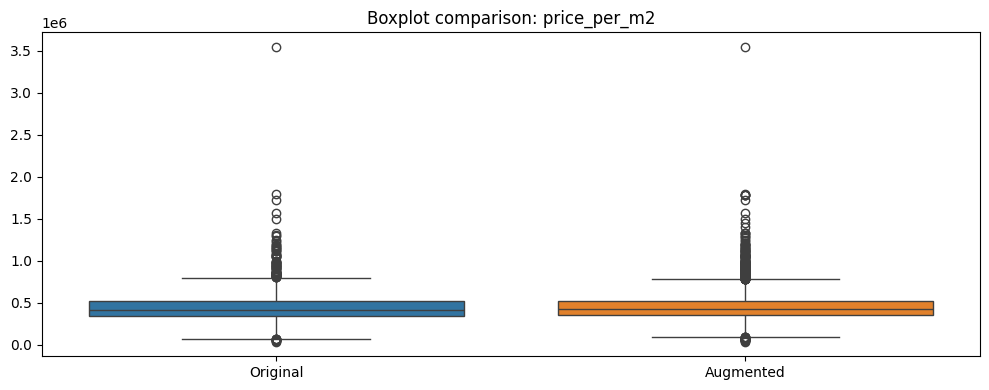

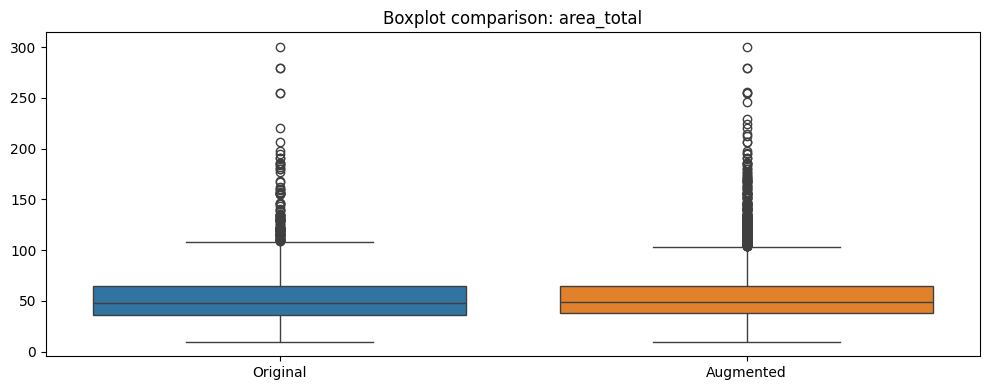

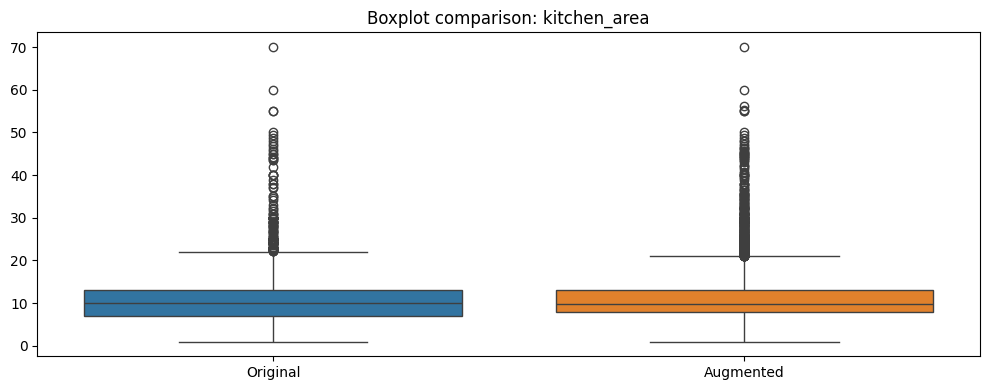

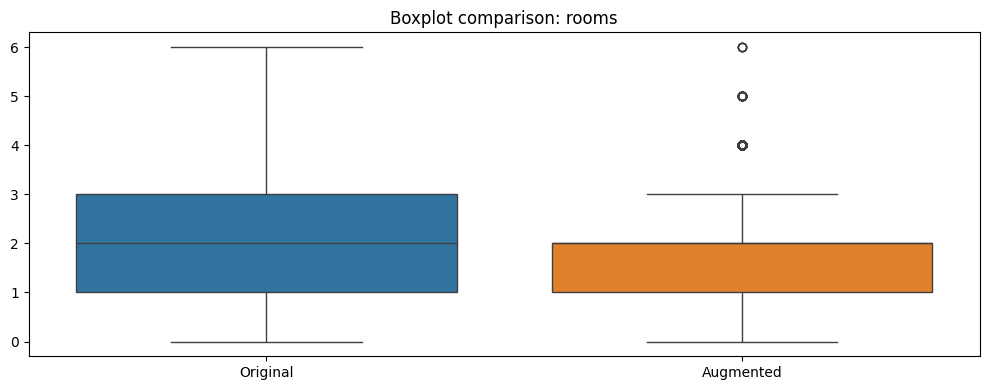

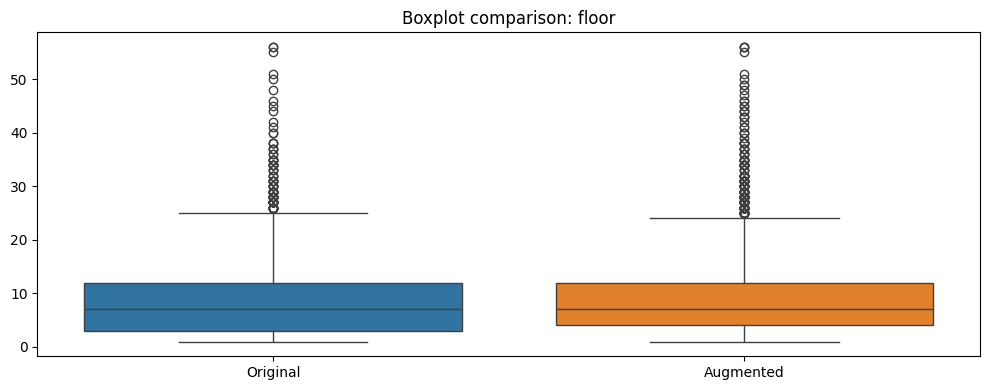

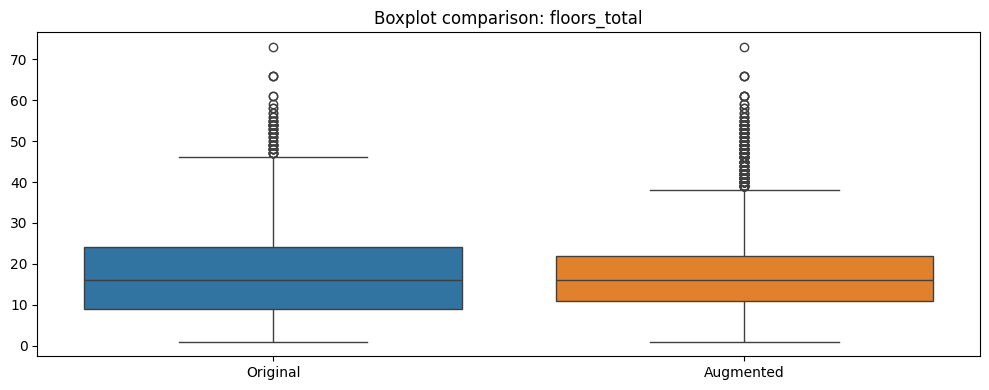

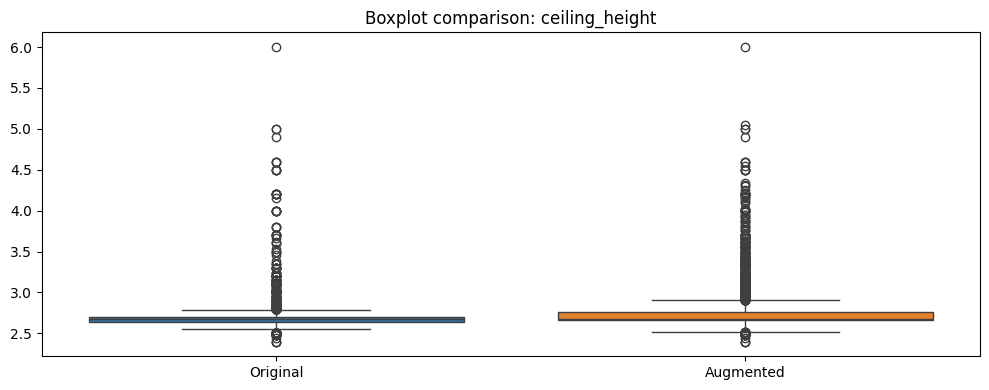

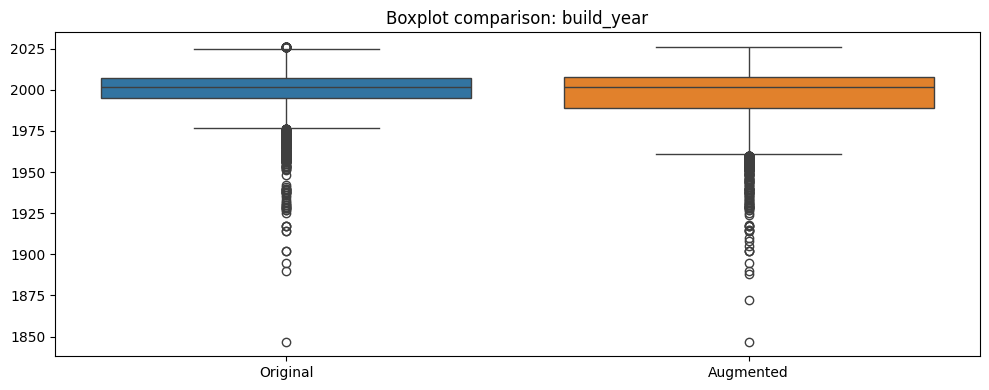

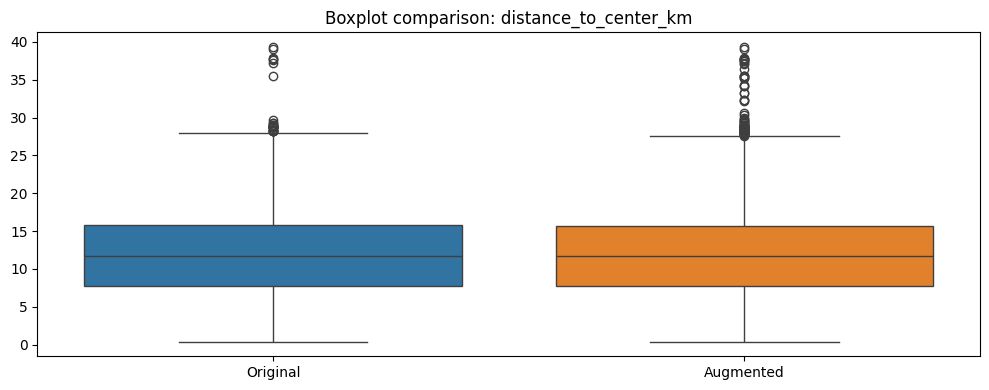

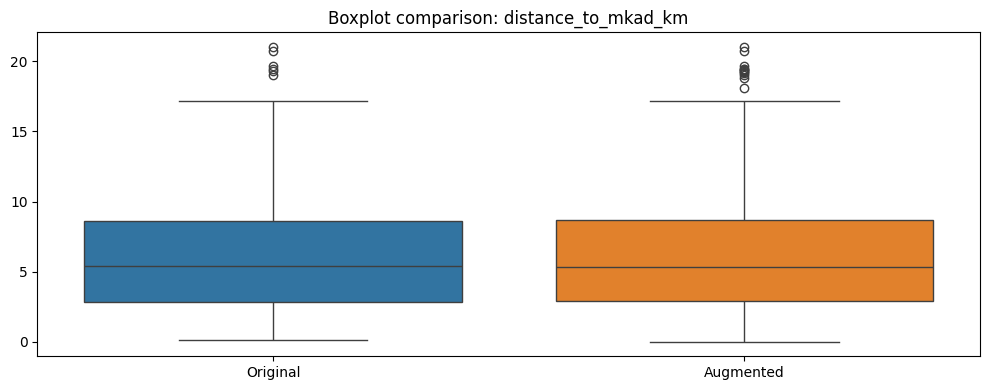

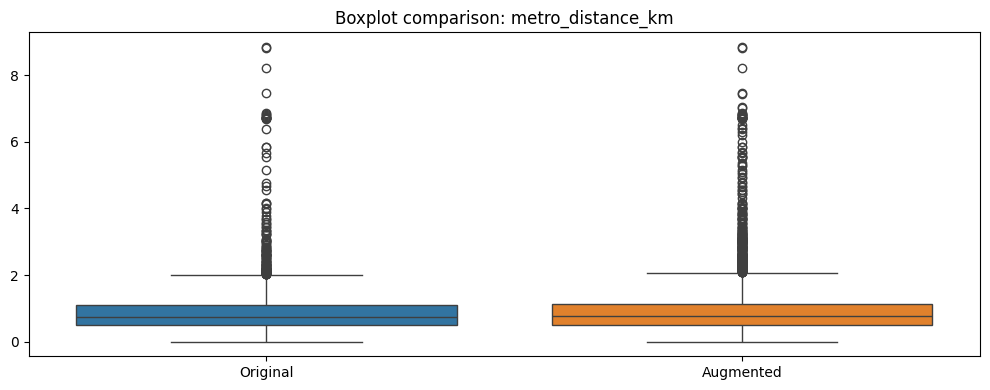

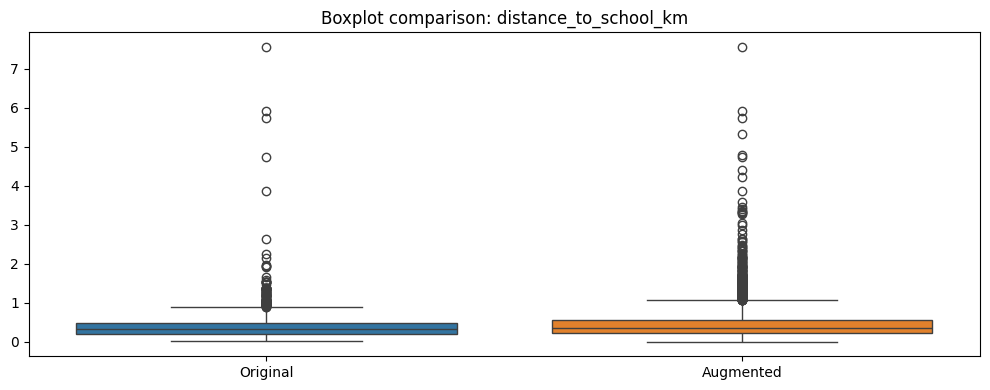

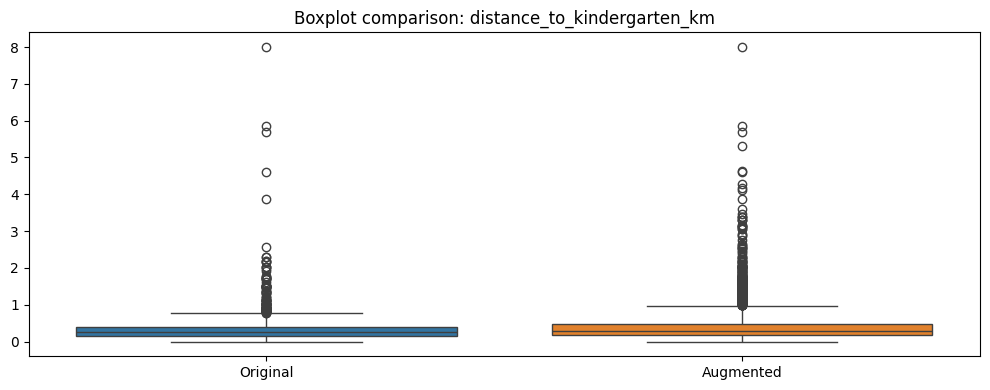

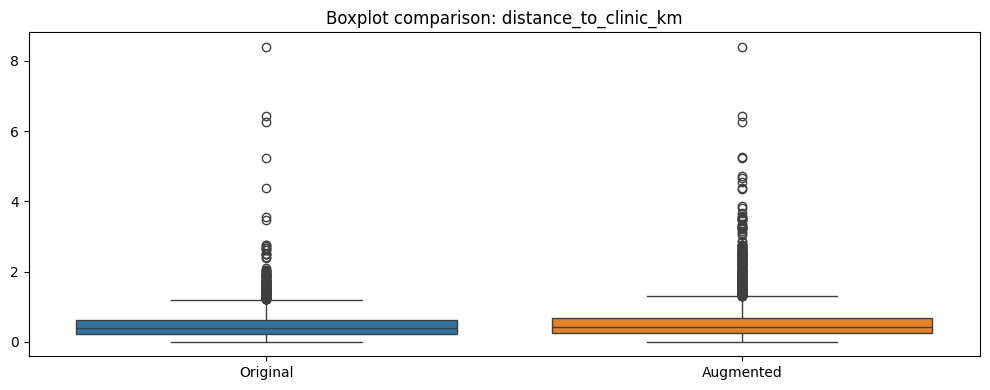

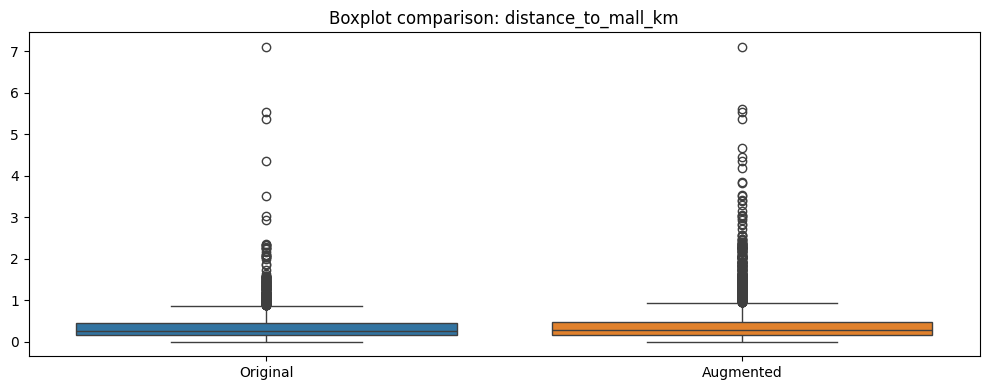

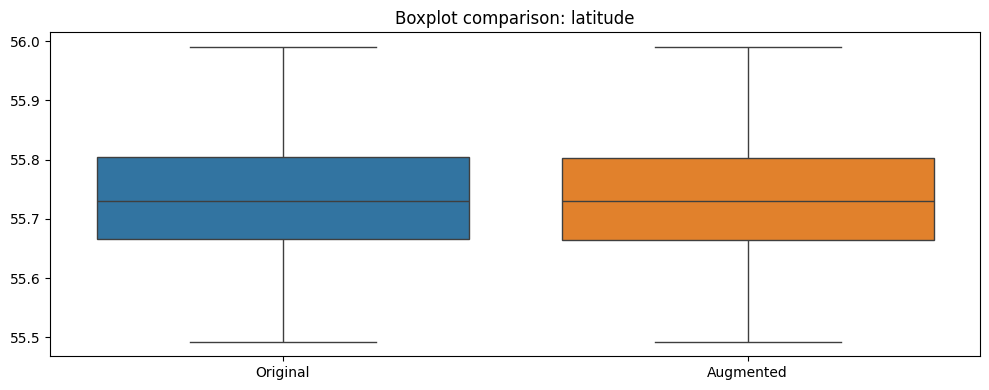

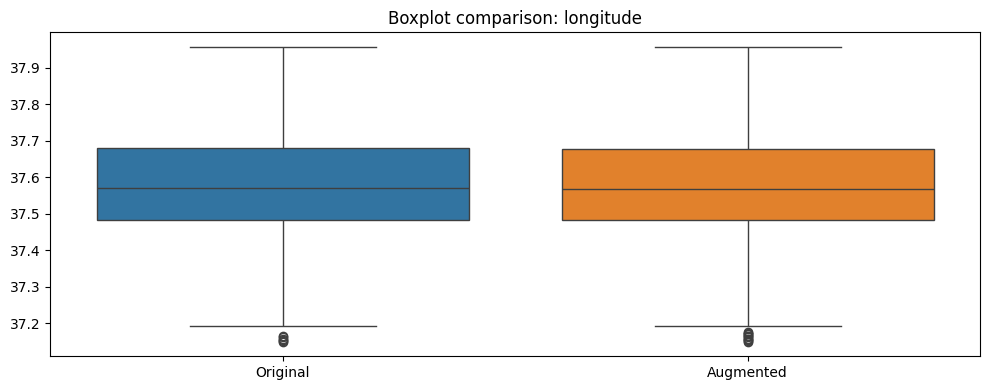

In [8]:
for feature in compare_features:

    plt.figure(figsize=(10, 4))

    box_df = pd.DataFrame({
        "Original": original_train[feature],
        "Augmented": train_augmented[feature]
    })

    sns.boxplot(data=box_df)

    plt.title(
        f"Boxplot comparison: {feature}"
    )

    plt.tight_layout()

    plt.savefig(
        f"boxplot_{feature}.png",
        dpi=250
    )

    plt.show()


## 8. География

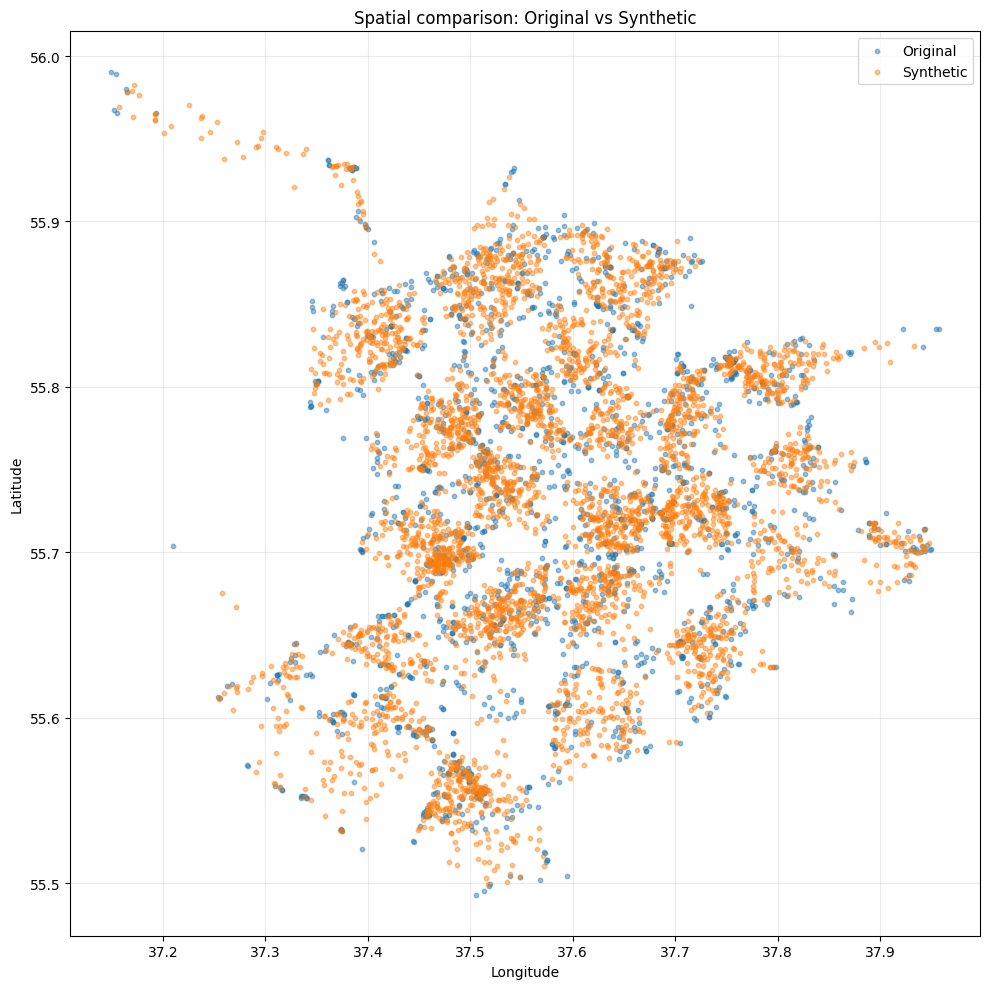

In [9]:
plt.figure(figsize=(10, 10))

plt.scatter(
    original_train["longitude"],
    original_train["latitude"],
    s=10,
    alpha=0.45,
    label="Original"
)

plt.scatter(
    synthetic["longitude"],
    synthetic["latitude"],
    s=10,
    alpha=0.45,
    label="Synthetic"
)

plt.title(
    "Spatial comparison: Original vs Synthetic"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "spatial_original_vs_synthetic.png",
    dpi=300
)

plt.show()


## 9. Корреляции

In [10]:
corr_features = [
    col for col in compare_features
    if (
        original_train[col].dtype != "object"
    )
]

corr_original = (
    original_train[corr_features]
    .corr(numeric_only=True)
)

corr_augmented = (
    train_augmented[corr_features]
    .corr(numeric_only=True)
)

corr_diff = (
    corr_augmented - corr_original
)


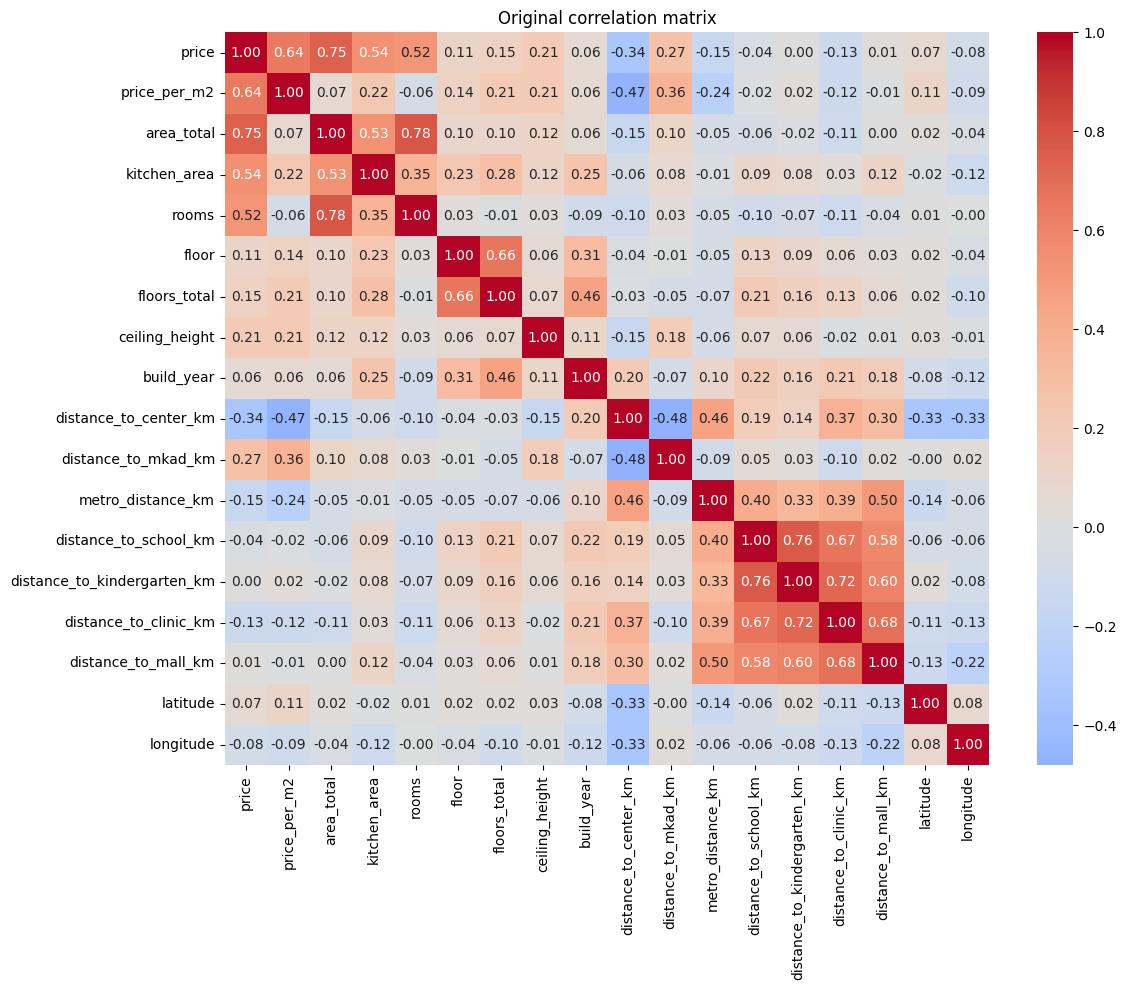

In [11]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_original,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Original correlation matrix")

plt.tight_layout()

plt.savefig(
    "corr_original.png",
    dpi=300
)

plt.show()


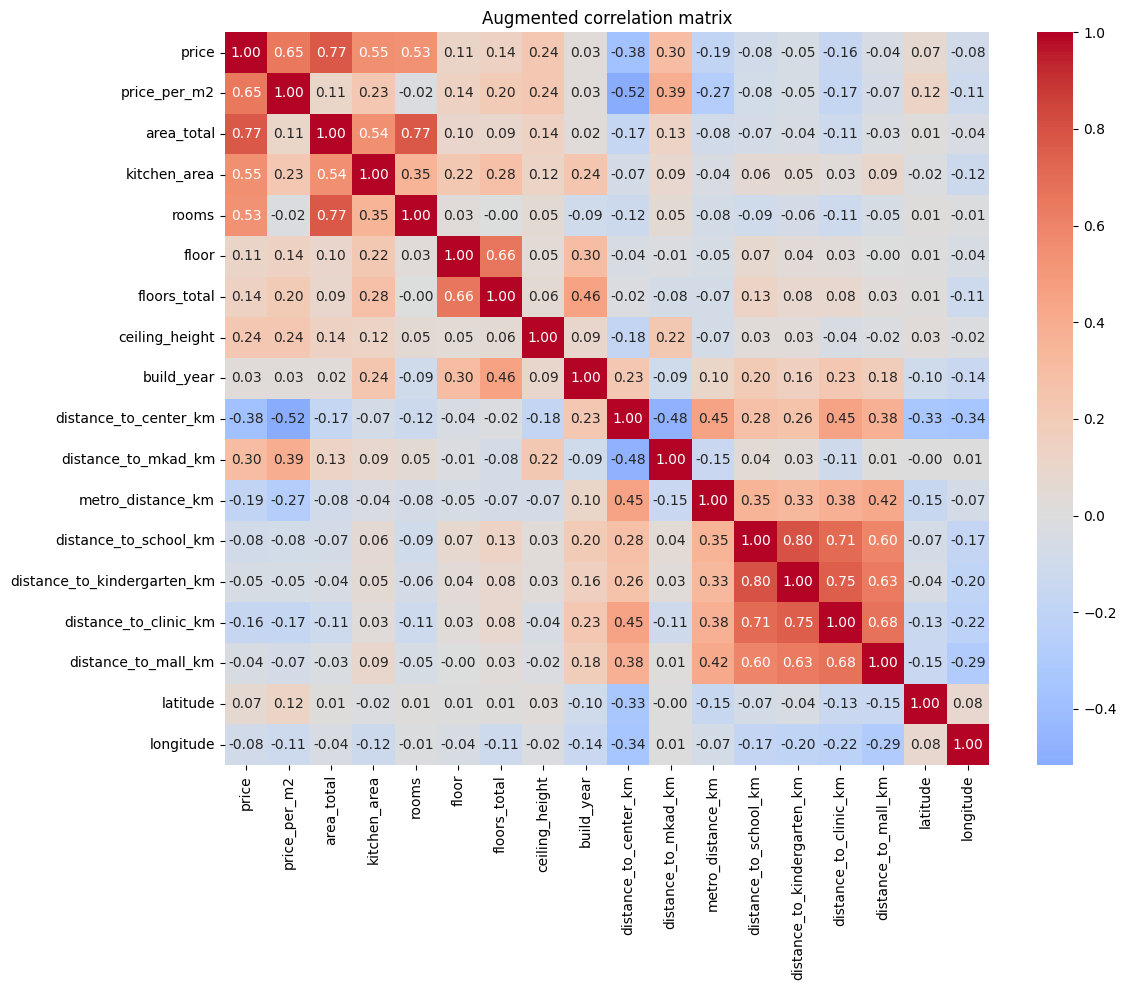

In [12]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_augmented,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Augmented correlation matrix")

plt.tight_layout()

plt.savefig(
    "corr_augmented.png",
    dpi=300
)

plt.show()


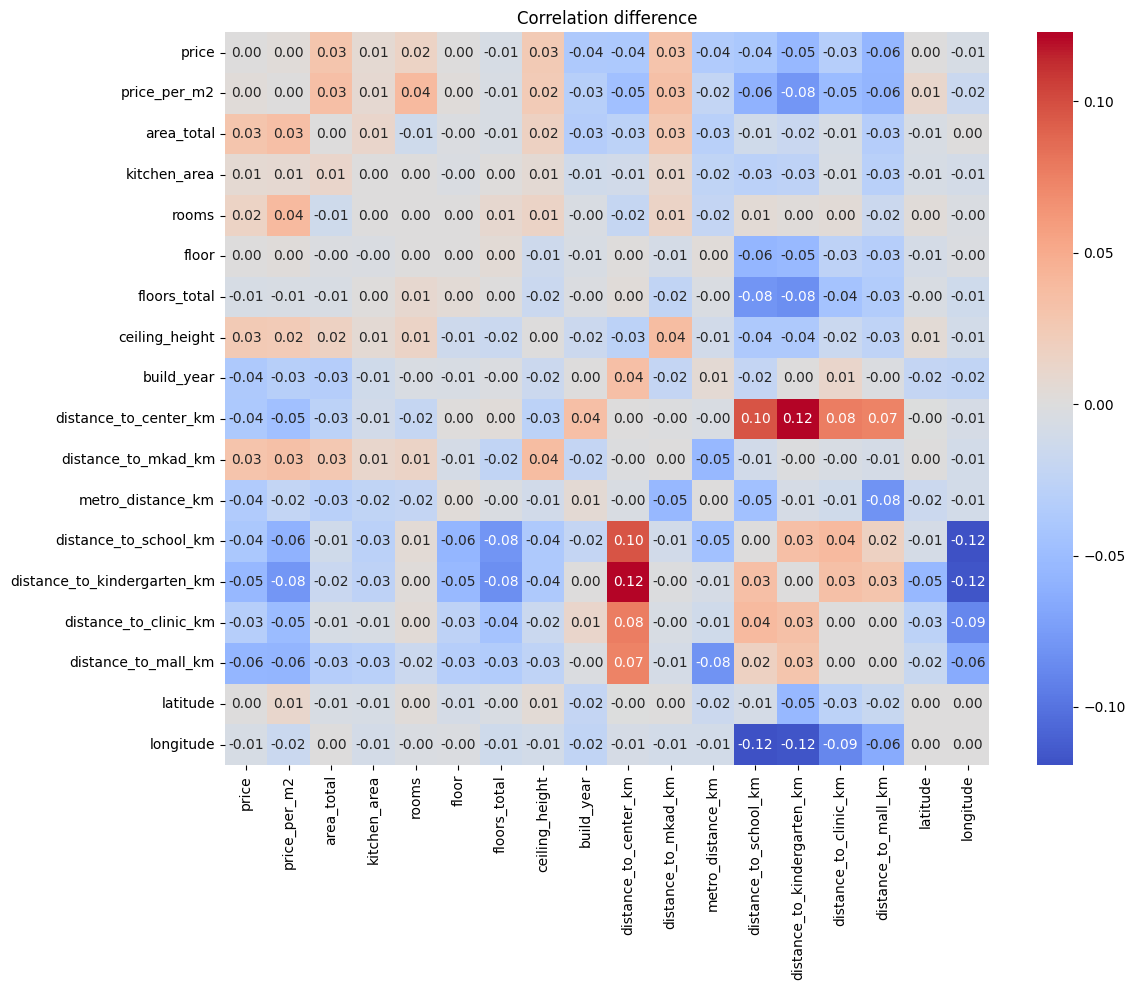

In [13]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_diff,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation difference")

plt.tight_layout()

plt.savefig(
    "corr_difference.png",
    dpi=300
)

plt.show()


## 10. Проверка synthetic realism

In [14]:
synthetic[compare_features].describe().T

,count,mean,std,min,25%,50%,75%,max
price,4136.0,2.532450e+07,1.764633e+07,4.023110e+06,1.551367e+07,2.025437e+07,2.848910e+07,2.142668e+08
price_per_m2,4136.0,4.549007e+05,1.522868e+05,5.461017e+04,3.562208e+05,4.276058e+05,5.233345e+05,1.782999e+06
area_total,4136.0,5.460514e+01,2.417875e+01,1.244567e+01,3.894916e+01,4.977411e+01,6.381159e+01,2.557088e+02
kitchen_area,4136.0,1.130629e+01,5.489118e+00,3.000000e+00,7.963883e+00,9.848575e+00,1.320287e+01,5.625106e+01
rooms,4108.0,1.860029e+00,8.275328e-01,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,6.000000e+00
floor,4136.0,8.987427e+00,6.246360e+00,1.000000e+00,4.000000e+00,8.000000e+00,1.200000e+01,5.600000e+01
floors_total,4136.0,1.776910e+01,8.604665e+00,3.000000e+00,1.200000e+01,1.600000e+01,2.200000e+01,6.100000e+01
ceiling_height,4136.0,2.750159e+00,1.932280e-01,2.487943e+00,2.661556e+00,2.682043e+00,2.776454e+00,5.051671e+00
build_year,4136.0,1.997590e+03,1.663342e+01,1.872000e+03,1.989000e+03,2.002000e+03,2.008000e+03,2.026000e+03
distance_to_center_km,4136.0,1.236045e+01,6.067962e+00,1.010000e+00,7.727500e+00,1.183500e+01,1.559250e+01,3.770000e+01


## 11. Проверка отрицательных значений

In [15]:
numeric_cols = train_augmented.select_dtypes(
    include=np.number
).columns

negative_report = {}

for col in numeric_cols:

    negative_count = (
        train_augmented[col] < 0
    ).sum()

    if negative_count > 0:
        negative_report[col] = negative_count

print(negative_report)


{}
